<table style="border: none; border-collapse: collapse;">
    <tr>
        <td style="width: 22%; vertical-align: middle; padding-right: 10px;">
            <img src="https://upload.wikimedia.org/wikipedia/commons/d/df/Logo_UNIR.png" width="250">
        </td>
        <td style="width: 2px; text-align: center;">
            <font color="#3facc9" size="7">|</font><br>
            <font color="#3facc9" size="7">|</font>
        </td>
        <td>
            <p style="font-variant: small-caps;"><font color="#3facc9" size="5">
                <b>Maestría en Computación Cuántica</b>
            </font> </p>
            <p style="font-variant: small-caps;"><font color="#3facc9" size="4">
                Computación Cuántica &bull; Actividad 2. Ejercicios con puertas lógicas cuánticas
            </font></p>
            <p style="font-style: oblique;"><font color="#3facc9" size="3">
                Andrés Merino &bull; Mayo 2026
            </font></p>
        </td>  
    </tr>
</table>

---
## <font color='3facc9'> Librerías necesarias </font>

Importamos las librerías necesarias:

* `numpy`: librería para operaciones numéricas y álgebra lineal.

* `IPython.display`: herramientas de visualización en notebooks.

* `qiskit`: librería para computación cuántica.

  * `QuantumCircuit`: construcción y representación de circuitos cuánticos.

* `qiskit.quantum_info`: herramientas para representar y analizar estados cuánticos.

  * `Statevector`: representación de estados cuánticos mediante vectores de amplitudes.
  * `DensityMatrix`: representación de estados cuánticos mediante matrices de densidad.
  * `state_fidelity`: cálculo de fidelidad entre estados cuánticos.

* `qiskit.visualization`: herramientas de visualización de estados cuánticos.

  * `plot_state_city`: representación gráfica de la matriz de densidad.
  * `plot_state_paulivec`: representación del estado en la base de operadores de Pauli.

* `qiskit_aer`: simuladores de circuitos cuánticos.

  * `AerSimulator`: simulador para ejecutar circuitos cuánticos y experimentos.

* `qiskit_experiments.library`: biblioteca de experimentos cuánticos.

  * `StateTomography`: implementación de tomografía de estado cuántico.


In [9]:
import numpy as np
from IPython.display import display, Markdown
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector, DensityMatrix, state_fidelity
from qiskit.visualization import plot_state_city, plot_state_paulivec
from qiskit_aer import AerSimulator
from qiskit_experiments.library import StateTomography

---
## <font color='3facc9'> Pautas de elaboración </font>

Implementar cuatro circuitos cuánticos de forma que cada uno de ellos haga evolucionar el estado del sistema a cada uno de los cuatro estados de Bell. Demostrar con las debidas mediciones que los circuitos funcionan correctamente. Debe utilizarse la librería Qiskit.



---
## <font color='3facc9'> Implementación </font>

### Definición de los circuitos de Bell


Los cuatro estados de Bell son:

$$|\Phi^+\rangle = \frac{1}{\sqrt{2}}(|00\rangle + |11\rangle)$$

$$|\Phi^-\rangle = \frac{1}{\sqrt{2}}(|00\rangle - |11\rangle)$$

$$|\Psi^+\rangle = \frac{1}{\sqrt{2}}(|01\rangle + |10\rangle)$$

$$|\Psi^-\rangle = \frac{1}{\sqrt{2}}(|01\rangle - |10\rangle)$$


Cada estado de Bell se prepara a partir del estado $|00\rangle$ aplicando una secuencia específica de puertas:

| Estado | Preparación |
|--------|-------------|
| $\|\Phi^+\rangle$ | $H$ en $q_0$ + CNOT |
| $\|\Phi^-\rangle$ | $X$ en $q_0$, $H$ en $q_0$ + CNOT |
| $\|\Psi^+\rangle$ | $X$ en $q_1$, $H$ en $q_0$ + CNOT |
| $\|\Psi^-\rangle$ | $X$ en $q_0$, $X$ en $q_1$, $H$ en $q_0$ + CNOT |

In [10]:
def circuito_phi_plus():
    qc = QuantumCircuit(2)
    qc.h(0)
    qc.cx(0, 1)
    return qc

def circuito_phi_minus():
    qc = QuantumCircuit(2)
    qc.x(0)
    qc.h(0)
    qc.cx(0, 1)
    return qc

def circuito_psi_plus():
    qc = QuantumCircuit(2)
    qc.x(1)
    qc.h(0)
    qc.cx(0, 1)
    return qc

def circuito_psi_minus():
    qc = QuantumCircuit(2)
    qc.x(0)
    qc.x(1)
    qc.h(0)
    qc.cx(0, 1)
    return qc

BELL_STATES = [
    {"nombre": r"|Φ+⟩",  "circuito": circuito_phi_plus},
    {"nombre": r"|Φ-⟩",  "circuito": circuito_phi_minus},
    {"nombre": r"|Ψ+⟩",  "circuito": circuito_psi_plus},
    {"nombre": r"|Ψ-⟩",  "circuito": circuito_psi_minus},
]

### Función de verificación


In [11]:
def verificar_estado_bell(estado, shots=2000):
    nombre = estado["nombre"]
    qc = estado["circuito"]()
    
    # Aplico el circuito para obtener el estado esperado
    vector_esperado = Statevector.from_instruction(qc)
    # Convierto el vector de estado esperado a una matriz de densidad
    matriz_esperada = DensityMatrix(vector_esperado)
    
    # Realizo una simulación de la tomografía de estado 
    backend = AerSimulator()
    experimento = StateTomography(qc)
    resultado = experimento.run(backend, shots=shots).block_for_results()

    # Extraigo la matriz de densidad del resultado
    df = resultado.analysis_results(dataframe=True)
    rho_tomografia = df[df["name"] == "state"]["value"].iloc[0]
    fidelidad = state_fidelity(rho_tomografia, matriz_esperada)

    # Visualizaciones
    display(Markdown("**Circuito**"))
    display(qc.draw("mpl"))

    display(Markdown("**Vector esperado**"))
    display(vector_esperado.draw("latex"))

    display(Markdown("**Matriz de densidad esperada**"))
    display(matriz_esperada.draw("latex"))
    
    display(Markdown("**Tomografía reconstruida**"))
    display(plot_state_city(rho_tomografia, title=f"Tomografía de {nombre}"))

    display(Markdown("**Representación de Pauli esperada**"))
    display(plot_state_paulivec(matriz_esperada, title=f"Pauli esperado {nombre}"))

    display(Markdown("**Tomografía reconstruida**"))
    display(plot_state_paulivec(rho_tomografia, title=f"Tomografía {nombre}"))

    display(Markdown("**Fidelidad**"))
    display(Markdown(f"Fidelidad entre el estado esperado y la tomografía: {fidelidad:.4f}"))

---
## <font color='3facc9'> Resultados </font>

Para cada uno de los cuatro estados de Bell se presenta:
- El circuito utilizado para su preparación
- El vector esperado del estado
- La matriz de densidad esperada
- La tomografía de estado obtenida a partir de la simulación
- La representación de Pauli del estado esperado
- La representación de Pauli del estado obtenido
- La fidelidad entre el estado esperado y el estado obtenido


#### Estado $|\Phi^+\rangle = \dfrac{1}{\sqrt{2}}(|00\rangle + |11\rangle)$

**Circuito**

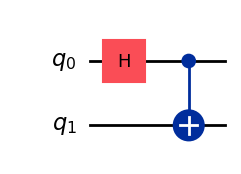

**Vector esperado**

<IPython.core.display.Latex object>

**Matriz de densidad esperada**

<IPython.core.display.Latex object>

**Tomografía reconstruida**

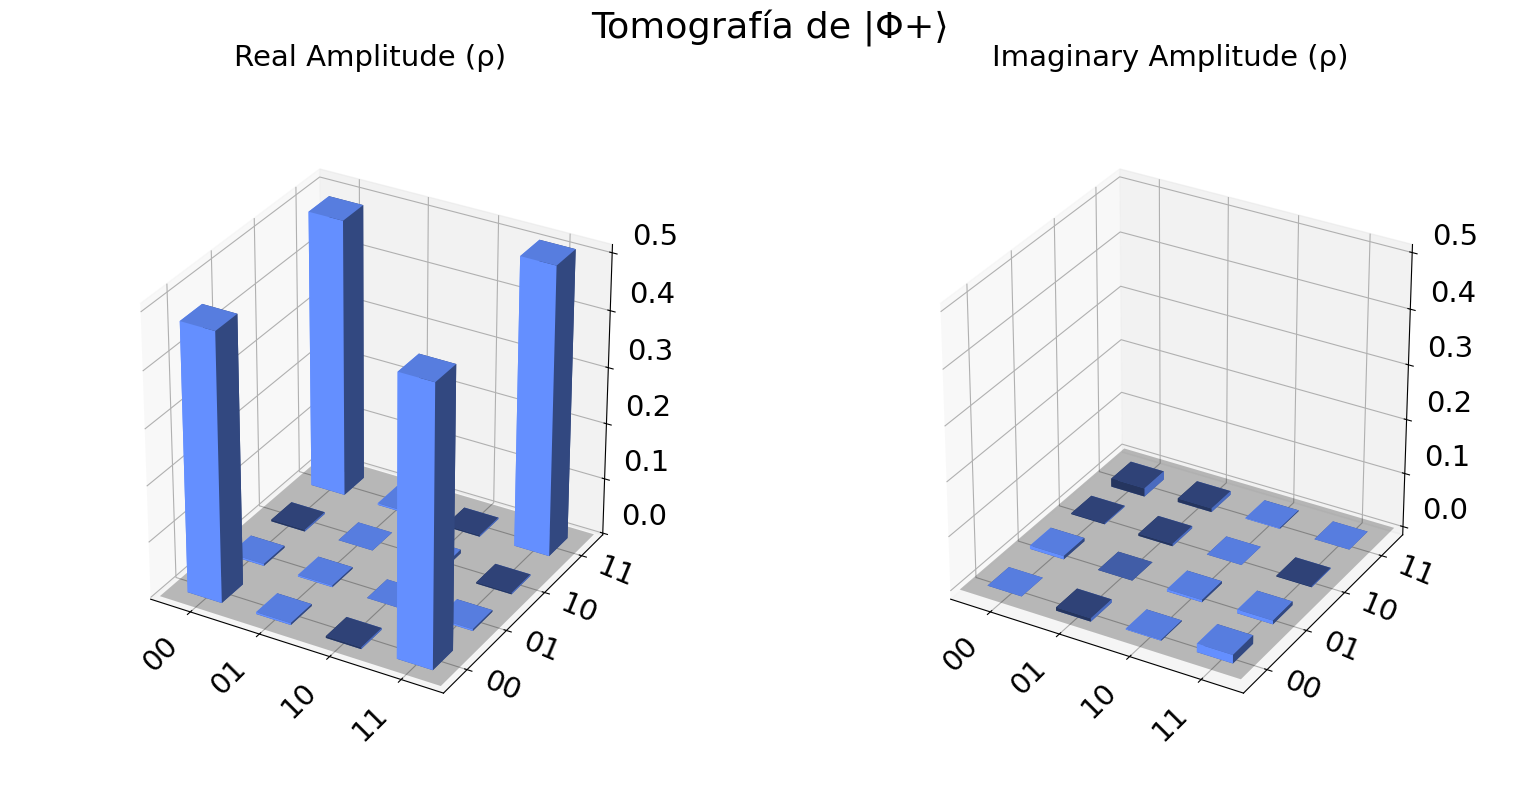

**Representación de Pauli esperada**

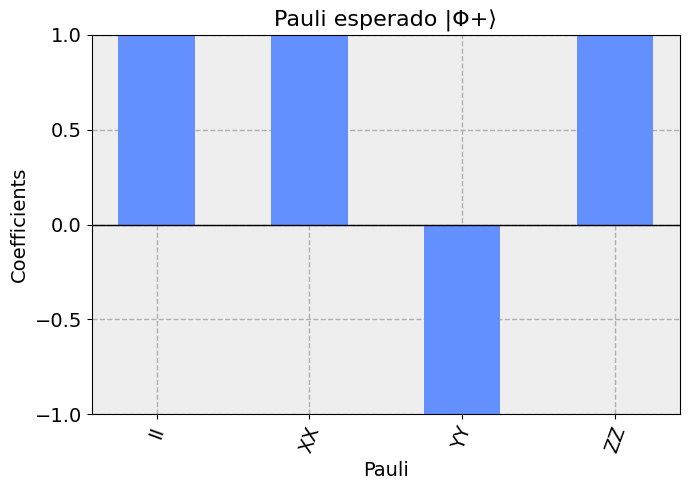

**Tomografía reconstruida**

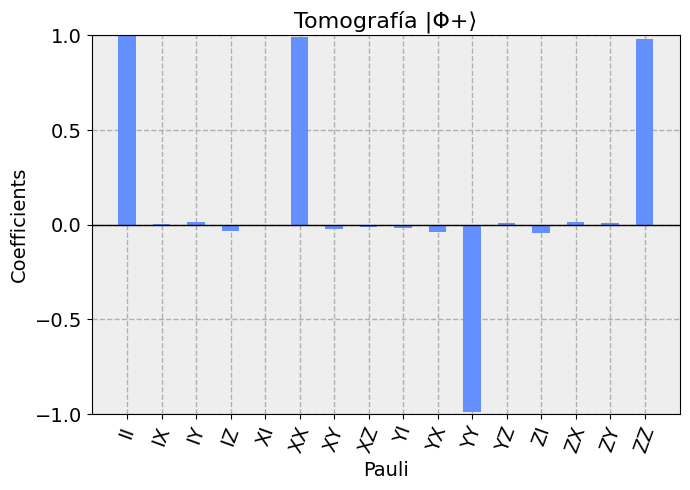

**Fidelidad**

Fidelidad entre el estado esperado y la tomografía: 0.9899

In [12]:
verificar_estado_bell(BELL_STATES[0])

#### Estado $|\Phi^-\rangle = \dfrac{1}{\sqrt{2}}(|00\rangle - |11\rangle)$

**Circuito**

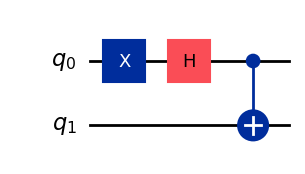

**Vector esperado**

<IPython.core.display.Latex object>

**Matriz de densidad esperada**

<IPython.core.display.Latex object>

**Tomografía reconstruida**

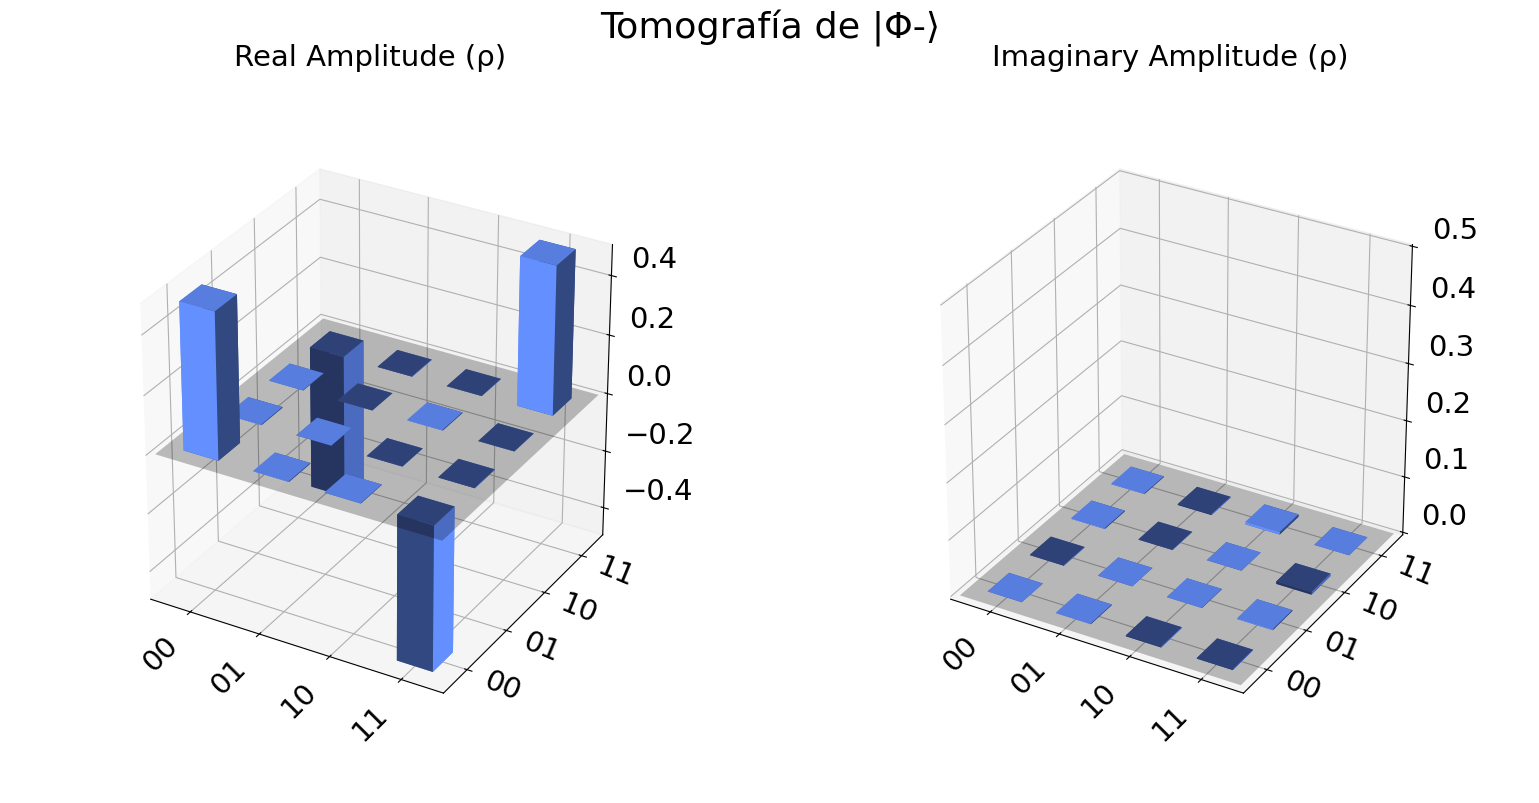

**Representación de Pauli esperada**

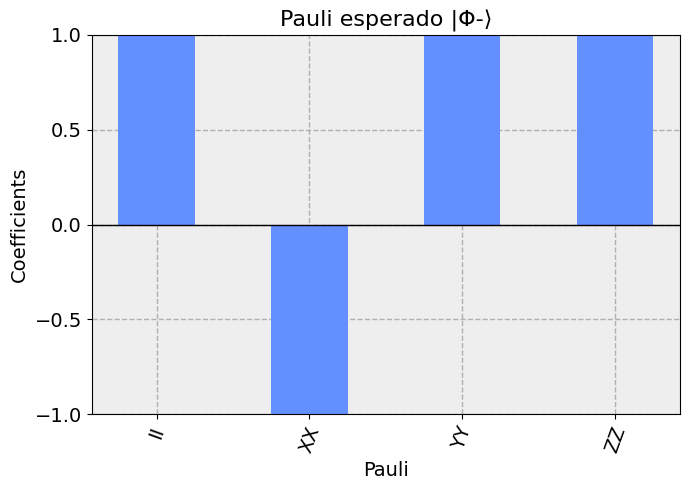

**Tomografía reconstruida**

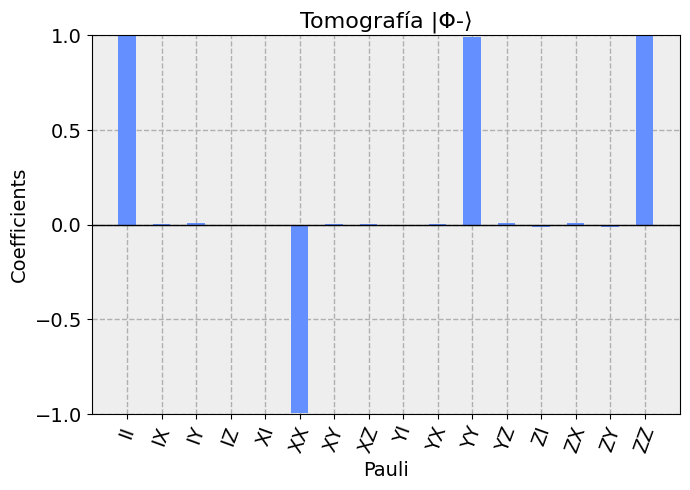

**Fidelidad**

Fidelidad entre el estado esperado y la tomografía: 0.9956

In [13]:
verificar_estado_bell(BELL_STATES[1])

#### Estado $|\Psi^+\rangle = \dfrac{1}{\sqrt{2}}(|01\rangle + |10\rangle)$


**Circuito**

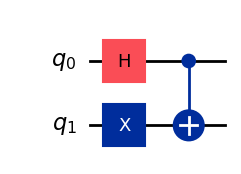

**Vector esperado**

<IPython.core.display.Latex object>

**Matriz de densidad esperada**

<IPython.core.display.Latex object>

**Tomografía reconstruida**

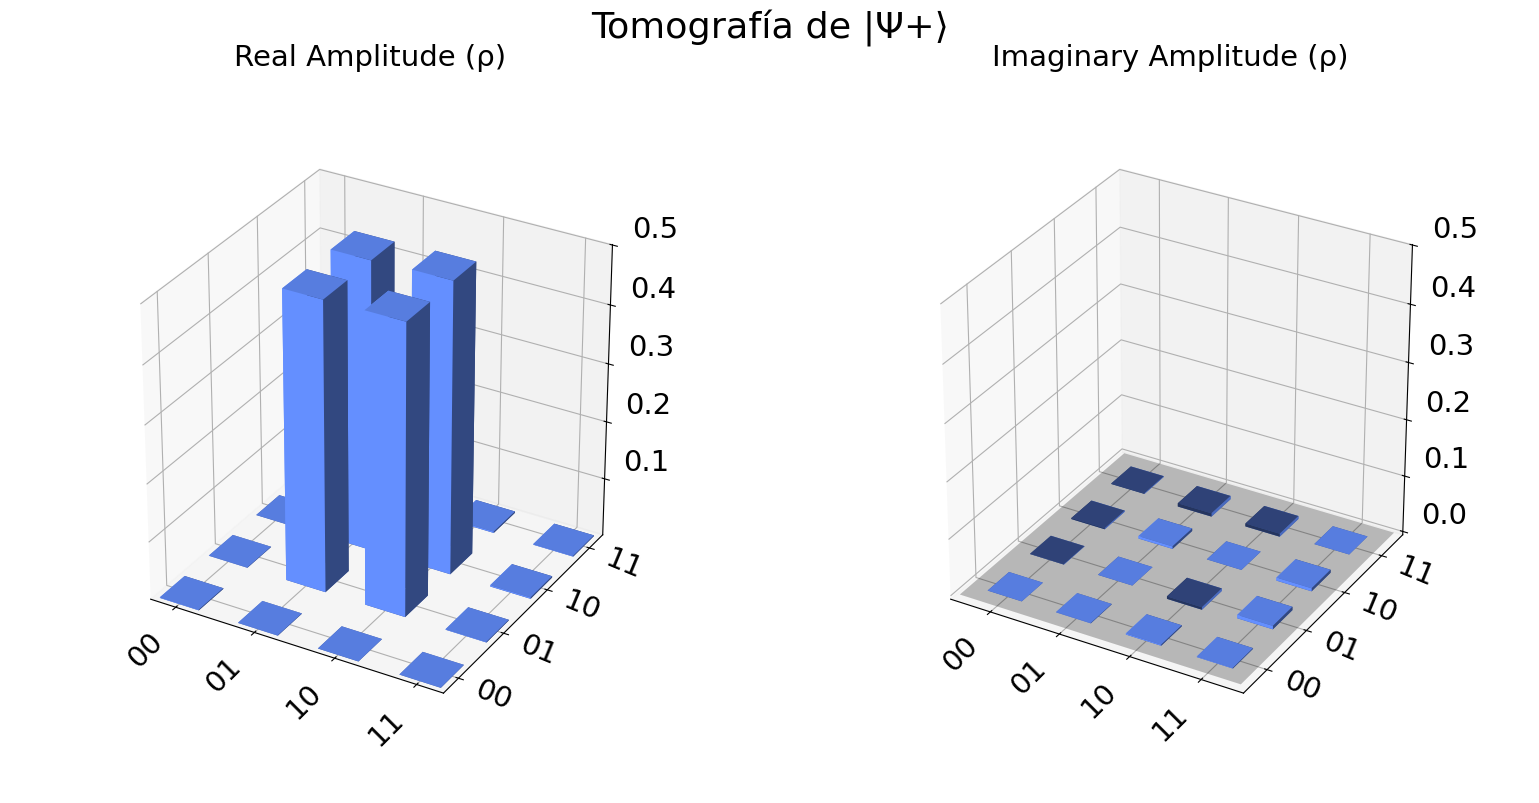

**Representación de Pauli esperada**

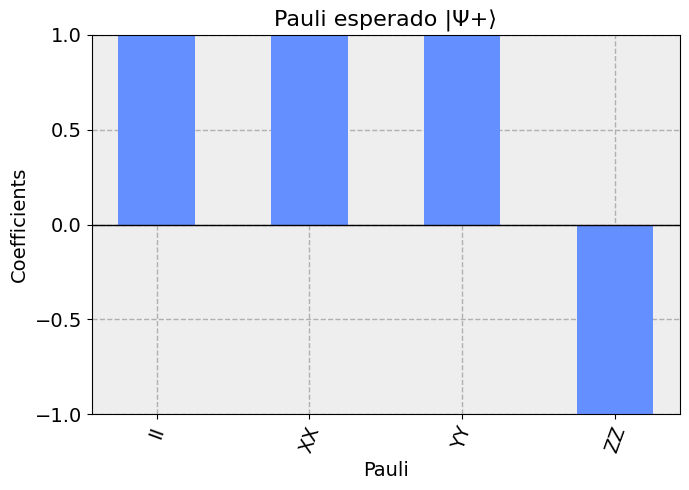

**Tomografía reconstruida**

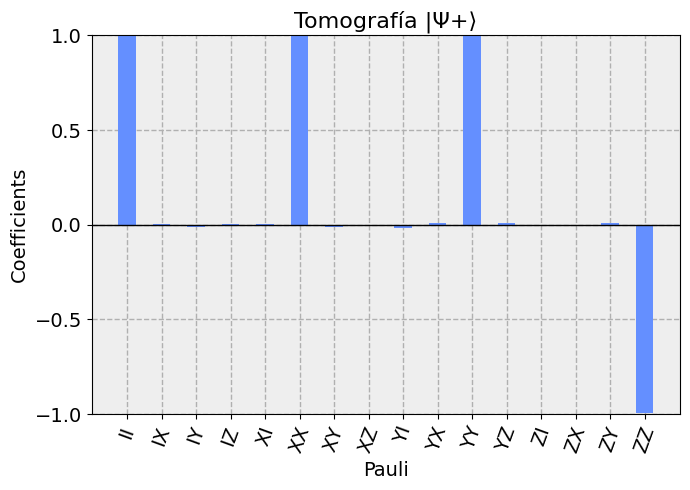

**Fidelidad**

Fidelidad entre el estado esperado y la tomografía: 0.9967

In [14]:
verificar_estado_bell(BELL_STATES[2])

#### Estado $|\Psi^-\rangle = \dfrac{1}{\sqrt{2}}(|01\rangle - |10\rangle)$

**Circuito**

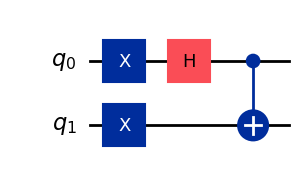

**Vector esperado**

<IPython.core.display.Latex object>

**Matriz de densidad esperada**

<IPython.core.display.Latex object>

**Tomografía reconstruida**

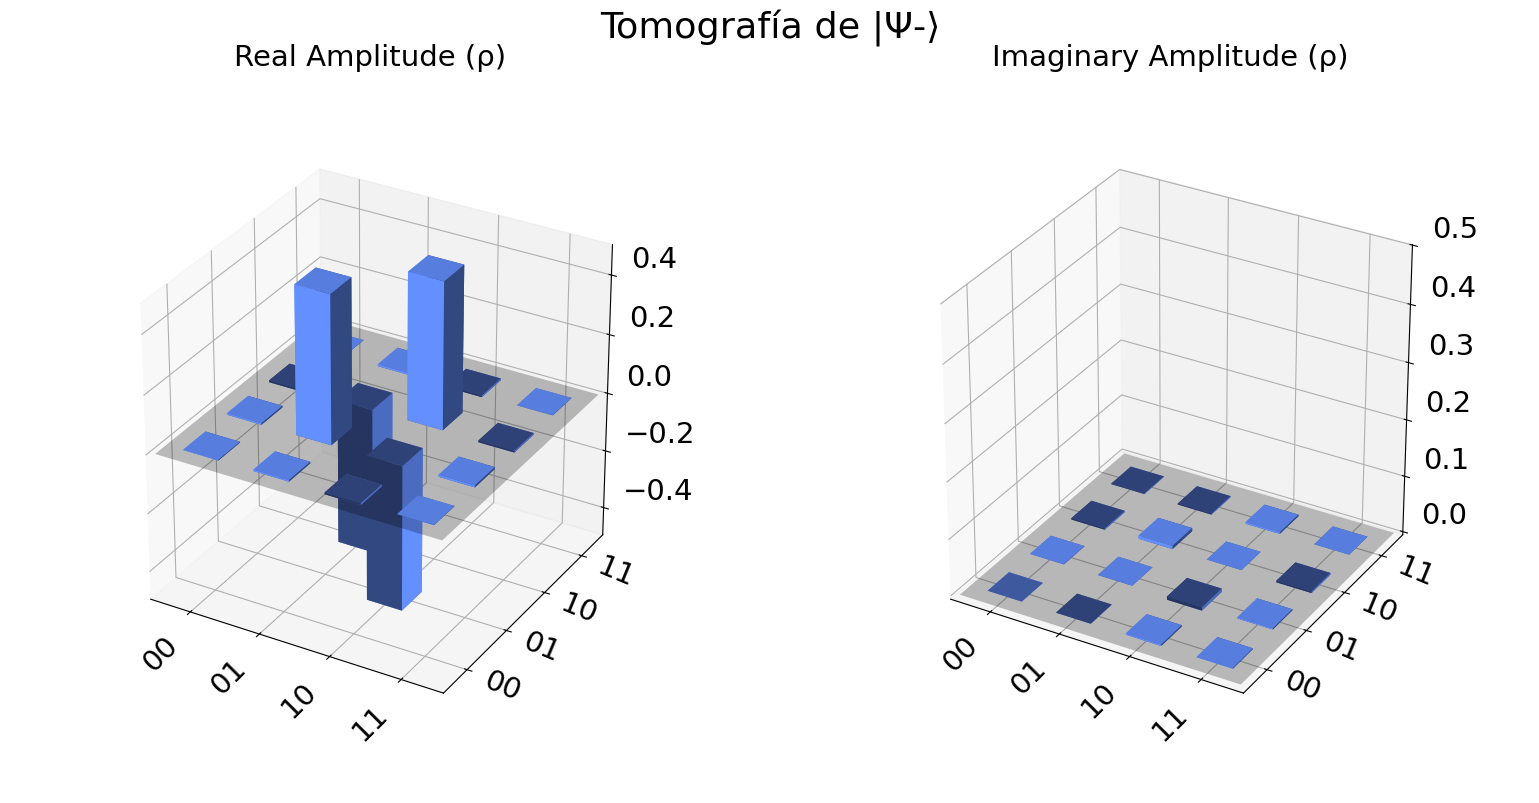

**Representación de Pauli esperada**

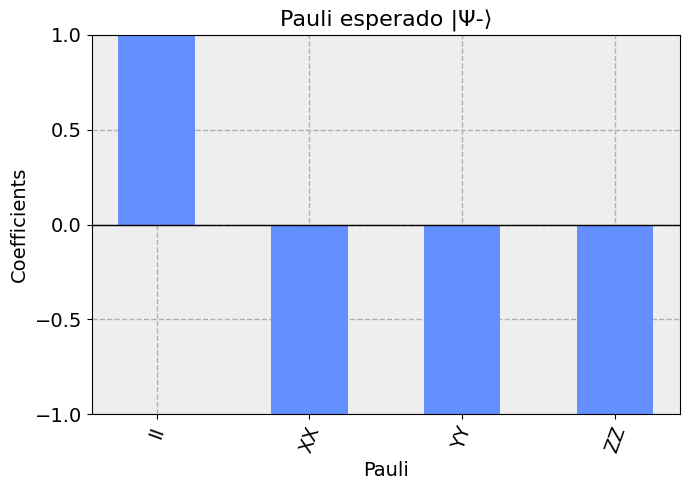

**Tomografía reconstruida**

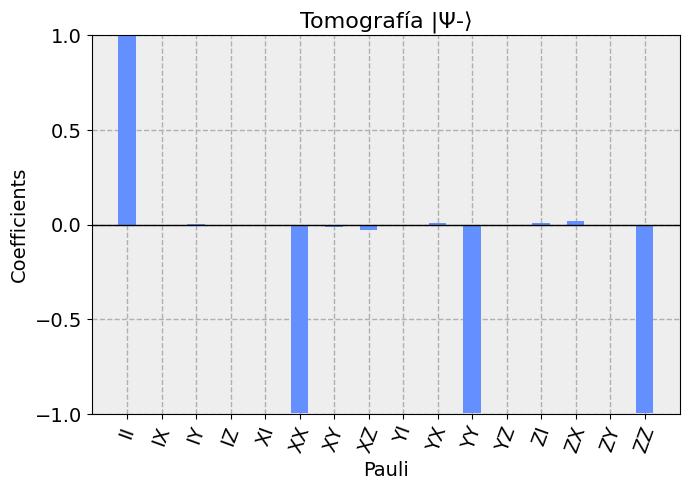

**Fidelidad**

Fidelidad entre el estado esperado y la tomografía: 0.9956

In [15]:
verificar_estado_bell(BELL_STATES[3])

---
## <font color='3facc9'> Resumen de fidelidades </font>

La siguiente tabla compila los resultados de fidelidad para los cuatro estados de Bell, confirmando que los circuitos producen exactamente los estados esperados.

In [16]:
backend = AerSimulator()

for estado in BELL_STATES:
    qc = estado["circuito"]()

    # Aplico el circuito para obtener el estado esperado
    vector_esperado = Statevector.from_instruction(qc)
    matriz_esperada = DensityMatrix(vector_esperado)

    # Realizo una simulación de la tomografía de estado
    experimento = StateTomography(qc)
    resultado = experimento.run(backend, shots=2000).block_for_results()

    # Extraigo la matriz de densidad del resultado
    df = resultado.analysis_results(dataframe=True)
    rho_tomografia = df[df["name"] == "state"]["value"].iloc[0]
    fidelidad = state_fidelity(rho_tomografia, matriz_esperada)

    # Visualizaciones
    display(Markdown(f"Fidelidad entre el estado esperado y la tomografía para ${estado['nombre']}$: {fidelidad:.4f}"))

Fidelidad entre el estado esperado y la tomografía para $|Φ+⟩$: 0.9954

Fidelidad entre el estado esperado y la tomografía para $|Φ-⟩$: 0.9925

Fidelidad entre el estado esperado y la tomografía para $|Ψ+⟩$: 0.9845

Fidelidad entre el estado esperado y la tomografía para $|Ψ-⟩$: 0.9946